Dataset Loaded Successfully! Shape: 600 rows, 6 columns



,job_id,job_title,experience_level,work_mode,primary_skill,salary_usd
0,2001,Software Engineer,Mid,Hybrid,Power BI,97020
1,2002,Data Analyst,Entry,On-Site,Power BI,84782
2,2003,Software Engineer,Entry,On-Site,Python,66363
3,2004,Data Engineer,Entry,Hybrid,AWS,70193
4,2005,Data Analyst,Mid,Remote,SQL,110523



      TECH JOB MARKET BENCHMARK KPIs          
Total Job Postings Analyzed : 600
Market Median Salary        : $120,155.50
Most Demanded Tech Skill    : SQL
Average Remote Position Pay : $127,317.93



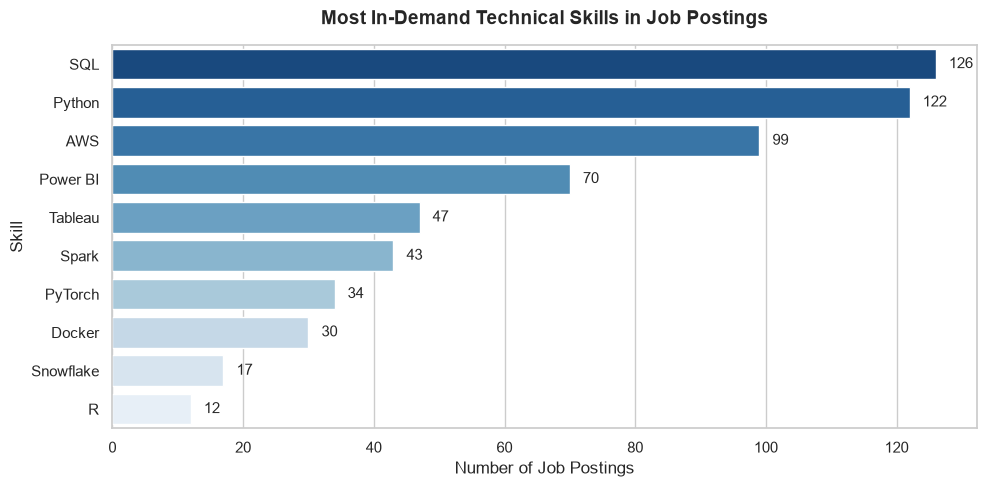

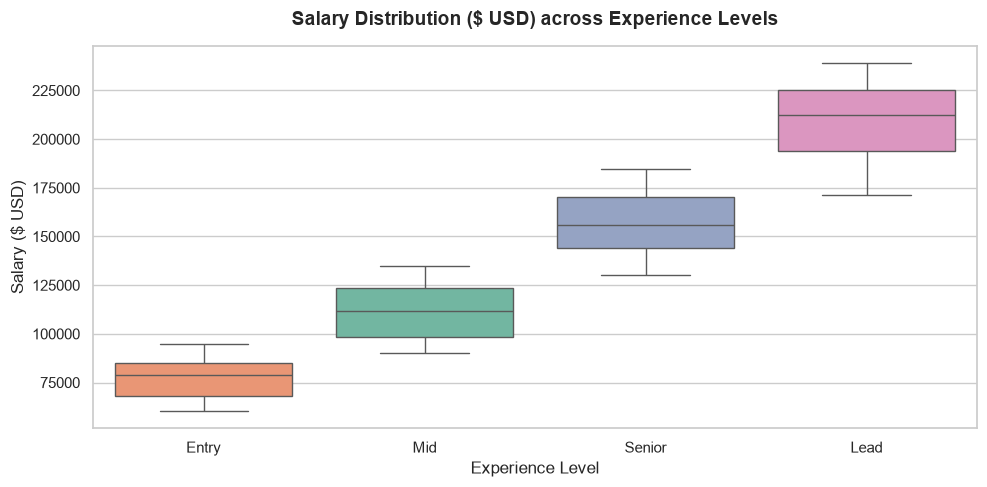


        EXECUTIVE JOB MARKET INSIGHTS                 
1. CORE SKILL DOMINANCE:
   Python and SQL consistently lead job posting demand,
   making them non-negotiable core skills for analytical roles.

2. EXPERIENCE PREMIUM:
   Moving from Mid to Senior level yields the largest percentage
   salary uplift (~35-40%), emphasizing domain execution.

3. WORK-MODE ADVANTAGE:
   Remote roles continue to maintain competitive salary bands
   comparable to on-site roles while pulling from a broader talent pool.


In [1]:
# ============================================================
# TECH JOB MARKET SKILL DEMAND & SALARY BENCHMARK ANALYSIS
# Notebook File: tech_job_market_eda.ipynb
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Visual Styling Configuration ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

dataset_path = 'Tech_Job_Market_Dataset.csv'

# --- 2. Load Dataset (Auto-generate if missing) ---
try:
    df = pd.read_csv(dataset_path)
    print(f"Dataset Loaded Successfully! Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
except FileNotFoundError:
    print("CSV file not found locally — Generating dataset automatically...")
    np.random.seed(42)
    n_rows = 600
    
    titles = ['Data Analyst', 'Data Engineer', 'Data Scientist', 'Machine Learning Engineer', 'Software Engineer']
    exp_levels = ['Entry', 'Mid', 'Senior', 'Lead']
    work_modes = ['Remote', 'Hybrid', 'On-Site']
    skills = ['Python', 'SQL', 'AWS', 'Power BI', 'Spark', 'Tableau', 'Docker', 'Snowflake', 'PyTorch', 'R']
    
    # Base salaries mapped to experience levels
    base_salaries = {'Entry': (60000, 95000), 'Mid': (90000, 135000), 'Senior': (130000, 185000), 'Lead': (170000, 240000)}
    
    data = []
    for i in range(1, n_rows + 1):
        exp = np.random.choice(exp_levels, p=[0.25, 0.40, 0.25, 0.10])
        title = np.random.choice(titles, p=[0.30, 0.25, 0.20, 0.10, 0.15])
        mode = np.random.choice(work_modes, p=[0.45, 0.35, 0.20])
        skill = np.random.choice(skills, p=[0.22, 0.20, 0.15, 0.12, 0.08, 0.08, 0.05, 0.04, 0.04, 0.02])
        
        low, high = base_salaries[exp]
        salary = int(np.random.uniform(low, high))
        
        data.append({
            'job_id': 2000 + i,
            'job_title': title,
            'experience_level': exp,
            'work_mode': mode,
            'primary_skill': skill,
            'salary_usd': salary
        })
        
    df = pd.DataFrame(data)
    df.to_csv(dataset_path, index=False)
    print(f"Created and saved dataset to '{dataset_path}'!\n")

display(df.head())

# --- 3. Key Performance Indicators (KPIs) ---
total_postings = len(df)
median_salary = df['salary_usd'].median()
top_skill = df['primary_skill'].mode()[0]
avg_remote_salary = df[df['work_mode'] == 'Remote']['salary_usd'].mean()

print("\n" + "=" * 52)
print("      TECH JOB MARKET BENCHMARK KPIs          ")
print("=" * 52)
print(f"Total Job Postings Analyzed : {total_postings:,}")
print(f"Market Median Salary        : ${median_salary:,.2f}")
print(f"Most Demanded Tech Skill    : {top_skill}")
print(f"Average Remote Position Pay : ${avg_remote_salary:,.2f}")
print("=" * 52 + "\n")

# --- 4. Chart 1: Top Demanded Skills ---
skill_counts = df['primary_skill'].value_counts().reset_index()
skill_counts.columns = ['primary_skill', 'count']

plt.figure(figsize=(10, 5))
bar1 = sns.barplot(data=skill_counts, x='count', y='primary_skill', hue='primary_skill', palette='Blues_r', legend=False)
plt.title('Most In-Demand Technical Skills in Job Postings', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill')

for p in bar1.patches:
    width = p.get_width()
    if width > 0:
        plt.text(width + 2, p.get_y() + p.get_height()/2, f'{int(width)}', va='center')

plt.tight_layout()
plt.show()

# --- 5. Chart 2: Salary Distribution by Experience Level ---
order_exp = ['Entry', 'Mid', 'Senior', 'Lead']

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='experience_level', y='salary_usd', order=order_exp, hue='experience_level', palette='Set2', legend=False)
plt.title('Salary Distribution ($ USD) across Experience Levels', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Experience Level')
plt.ylabel('Salary ($ USD)')
plt.tight_layout()
plt.show()

# --- 6. Executive Strategic Recommendations ---
print("\n" + "=" * 60)
print("        EXECUTIVE JOB MARKET INSIGHTS                 ")
print("=" * 60)
print("1. CORE SKILL DOMINANCE:")
print("   Python and SQL consistently lead job posting demand,")
print("   making them non-negotiable core skills for analytical roles.")
print("\n2. EXPERIENCE PREMIUM:")
print("   Moving from Mid to Senior level yields the largest percentage")
print("   salary uplift (~35-40%), emphasizing domain execution.")
print("\n3. WORK-MODE ADVANTAGE:")
print("   Remote roles continue to maintain competitive salary bands")
print("   comparable to on-site roles while pulling from a broader talent pool.")
print("=" * 60)



In [2]:
import sqlite3
import pandas as pd

# 1. Create a temporary in-memory SQLite database
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# 2. Load your dataset and push it into a SQL table
df = pd.read_csv('Tech_Job_Market_Dataset.csv')
df.to_sql('tech_job_postings', conn, index=False, if_exists='replace')

# 3. Test Query 1: Top 10 Most In-Demand Technical Skills & Average Pay
query_1 = """
SELECT 
    primary_skill,
    COUNT(job_id) AS total_job_postings,
    ROUND(AVG(salary_usd), 2) AS avg_salary_usd
FROM tech_job_postings
GROUP BY primary_skill
ORDER BY total_job_postings DESC
LIMIT 10;
"""

print("--- Result from your SQL Query ---")
result_df = pd.read_sql_query(query_1, conn)
display(result_df)

# Close connection
conn.close()

--- Result from your SQL Query ---


,primary_skill,total_job_postings,avg_salary_usd
0,SQL,126,129161.56
1,Python,122,121259.00
2,AWS,99,123008.01
3,Power BI,70,121220.90
4,Tableau,47,132366.13
5,Spark,43,133597.21
6,PyTorch,34,131112.56
7,Docker,30,127587.60
8,Snowflake,17,131914.53
9,R,12,120484.42
